In [1]:
import duckdb
from pathlib import Path

In [2]:
# Connect to the DuckDB file directly
db_path = Path("../data/macro_analytics.duckdb")
con = duckdb.connect(str(db_path))

# Run analytical queries directly using DuckDB SQL
df = con.execute("""
    SELECT 
        metric_date,
        yield_10y,
        oil_wti,
        CORR(yield_10y, oil_wti) OVER (
            ORDER BY metric_date ROWS BETWEEN 30 PRECEDING AND CURRENT ROW
        ) as rolling_30d_corr
    FROM fact_macro_metrics
    WHERE yield_10y IS NOT NULL AND oil_wti IS NOT NULL
    ORDER BY metric_date DESC
    LIMIT 10;
""").df()

print(df)

  metric_date  yield_10y  oil_wti  rolling_30d_corr
0  2026-07-17       4.55    79.20          0.315428
1  2026-07-16       4.57    79.20          0.263307
2  2026-07-15       4.55    79.20          0.244131
3  2026-07-14       4.58    79.20          0.205693
4  2026-07-13       4.62    79.20          0.197453
5  2026-07-10       4.56    72.45          0.209684
6  2026-07-09       4.54    73.15          0.241940
7  2026-07-08       4.56    74.56          0.286827
8  2026-07-07       4.55    71.53          0.366307
9  2026-07-06       4.48    69.60          0.506642


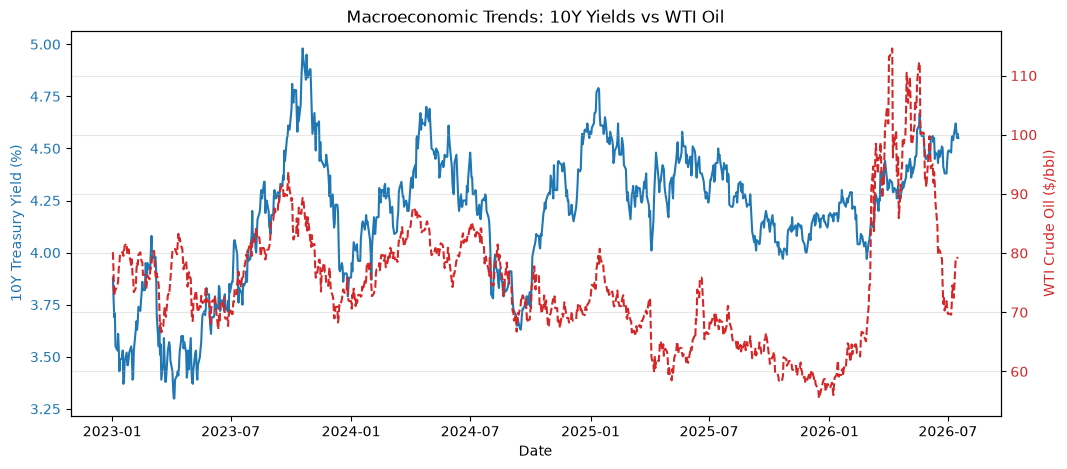

In [3]:
import matplotlib.pyplot as plt

# Pull full dataset from DuckDB
full_df = con.execute("""
    SELECT metric_date, yield_10y, oil_wti 
    FROM fact_macro_metrics 
    WHERE yield_10y IS NOT NULL AND oil_wti IS NOT NULL
    ORDER BY metric_date ASC
""").df()

# Plot dual-axis chart
fig, ax1 = plt.subplots(figsize=(12, 5))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('10Y Treasury Yield (%)', color=color)
ax1.plot(full_df['metric_date'], full_df['yield_10y'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('WTI Crude Oil ($/bbl)', color=color)
ax2.plot(full_df['metric_date'], full_df['oil_wti'], color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Macroeconomic Trends: 10Y Yields vs WTI Oil')
plt.grid(True, alpha=0.3)
plt.show()

## Rolling 30-Day Correlation

The dual-axis chart above shows raw levels, but not how tightly the two series move together over time. Plot the 30-day rolling correlation (computed in DuckDB) as its own series to see when the yield/oil relationship strengthens, weakens, or flips sign.

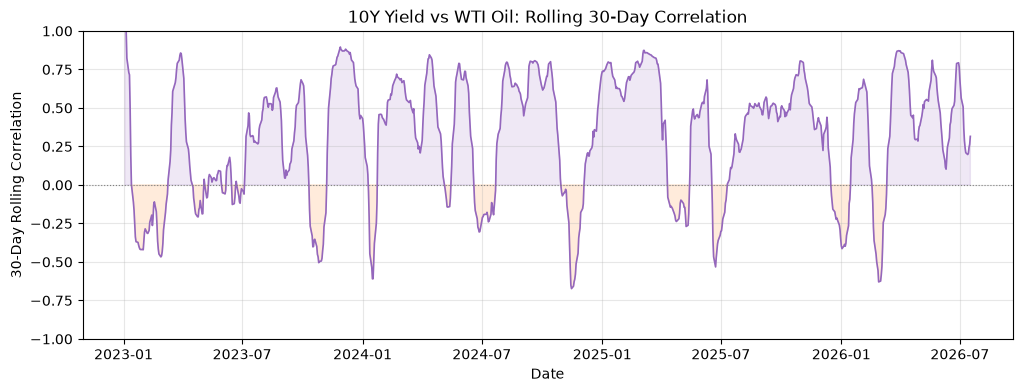

In [4]:

# Pull the full series plus its 30-day rolling correlation from DuckDB
corr_df = con.execute("""
    SELECT
        metric_date,
        yield_10y,
        oil_wti,
        CORR(yield_10y, oil_wti) OVER (
            ORDER BY metric_date ROWS BETWEEN 30 PRECEDING AND CURRENT ROW
        ) as rolling_30d_corr
    FROM fact_macro_metrics
    WHERE yield_10y IS NOT NULL AND oil_wti IS NOT NULL
    ORDER BY metric_date ASC
""").df()

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(corr_df['metric_date'], corr_df['rolling_30d_corr'], color='tab:purple', linewidth=1.2)
ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')

# Shade positive vs negative correlation regimes
ax.fill_between(
    corr_df['metric_date'], corr_df['rolling_30d_corr'], 0,
    where=(corr_df['rolling_30d_corr'] >= 0), color='tab:purple', alpha=0.15, interpolate=True
)
ax.fill_between(
    corr_df['metric_date'], corr_df['rolling_30d_corr'], 0,
    where=(corr_df['rolling_30d_corr'] < 0), color='tab:orange', alpha=0.15, interpolate=True
)

ax.set_xlabel('Date')
ax.set_ylabel('30-Day Rolling Correlation')
ax.set_ylim(-1, 1)
ax.set_title('10Y Yield vs WTI Oil: Rolling 30-Day Correlation')
ax.grid(True, alpha=0.3)
plt.show()